In [4]:
!pip install pandas pillow

In [5]:
!pip install pandas
!pip install opencv-python

In [6]:
!pip install tensorflow==2.12.0
!pip install keras

Found 2475 files belonging to 2 classes.
Using 1980 files for training.
Found 2475 files belonging to 2 classes.
Using 495 files for validation.
Class Names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']
Class Weights: {0: 1.243718592964824, 1: 0.8361486486486487}
Epoch 1/10
62/62 [==============================] - 104s 1s/step - loss: 0.6436 - accuracy: 0.6949 - val_loss: 0.3243 - val_accuracy: 0.8727
Epoch 2/10
62/62 [==============================] - 90s 1s/step - loss: 0.4134 - accuracy: 0.8172 - val_loss: 0.2689 - val_accuracy: 0.8848
Epoch 3/10
62/62 [==============================] - 90s 1s/step - loss: 0.3674 - accuracy: 0.8369 - val_loss: 0.2887 - val_accuracy: 0.8646
Epoch 4/10
62/62 [==============================] - 88s 1s/step - loss: 0.3464 - accuracy: 0.8540 - val_loss: 0.3064 - val_accuracy: 0.8465
Epoch 5/10
62/62 [==============================] - 88s 1s/step - loss: 0.3058 - accuracy: 0.8682 - val_loss: 0.4242 - val_accuracy: 0.8101
Epoch 6/10
62/62 [==

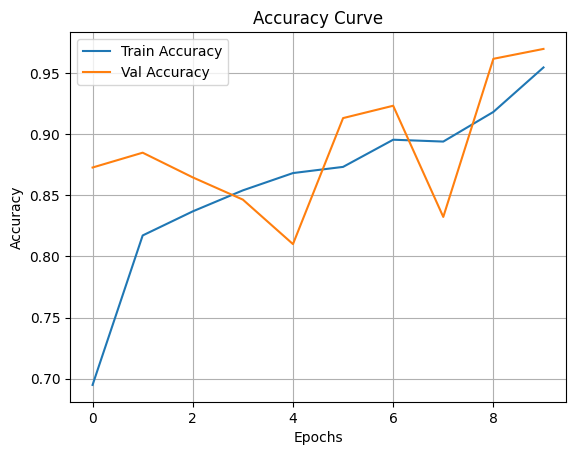

In [15]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Set constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE

# Data path
dataset_path = "/kaggle/input/pepper-bell-leaf-diseases/Pepper__bell Leaf Diseases Dataset From Bangladesh"
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class Names:", class_names)

# Data augmentation
data_augmentation = keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Preprocessing
def preprocess(ds, augment=False):
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = preprocess(train_ds, augment=True)
val_ds = preprocess(val_ds, augment=False)

# Compute class weights
labels = np.concatenate([y.numpy() for _, y in train_ds])
class_weights_raw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_raw)}
print("Class Weights:", class_weights)

# Vision Transformer parameters
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 6

# Patch creation layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Patch encoder
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

# MLP block
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Transformer block
def transformer_block(x, num_heads, projection_dim, transformer_units, dropout_rate):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
    )(x1, x1)
    x2 = layers.Add()([attention_output, x])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    
    # Fix: last Dense layer output matches projection_dim
    x3 = mlp(x3, hidden_units=[transformer_units, projection_dim], dropout_rate=dropout_rate)
    
    return layers.Add()([x3, x2])

# ViT Model
def build_vit_model():
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    patches = Patches(PATCH_SIZE)(inputs)
    encoded_patches = PatchEncoder(NUM_PATCHES, EMBED_DIM)(patches)

    for _ in range(NUM_LAYERS):
        encoded_patches = transformer_block(
            encoded_patches, NUM_HEADS, EMBED_DIM, FF_DIM, 0.1
        )

    x = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.1)(x)
    x = mlp(x, hidden_units=[FF_DIM], dropout_rate=0.1)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
vit_model = build_vit_model()

# Compile
vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "vit_model.h5", save_best_only=True
)
earlystop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Train
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, earlystop_cb],
    class_weight=class_weights
)

# Evaluate
loss, accuracy = vit_model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Plot results
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.title("Accuracy Curve")
plt.show()


In [16]:
#Evaluate
true_labels = []
pred_labels = []

for images, labels in val_ds:
    preds = vit_model.predict(images)
    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(preds, axis=1))

1/1 [==============================] - 1s 956ms/step


Classification Report:
                                precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.98      0.94      0.96       201
       Pepper__bell___healthy       0.96      0.99      0.97       294

                     accuracy                           0.97       495
                    macro avg       0.97      0.97      0.97       495
                 weighted avg       0.97      0.97      0.97       495



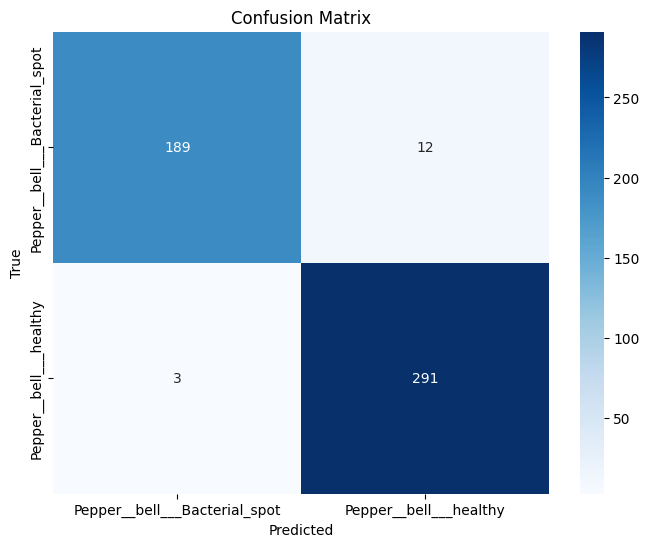

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vit_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Print classification report
print("Classification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


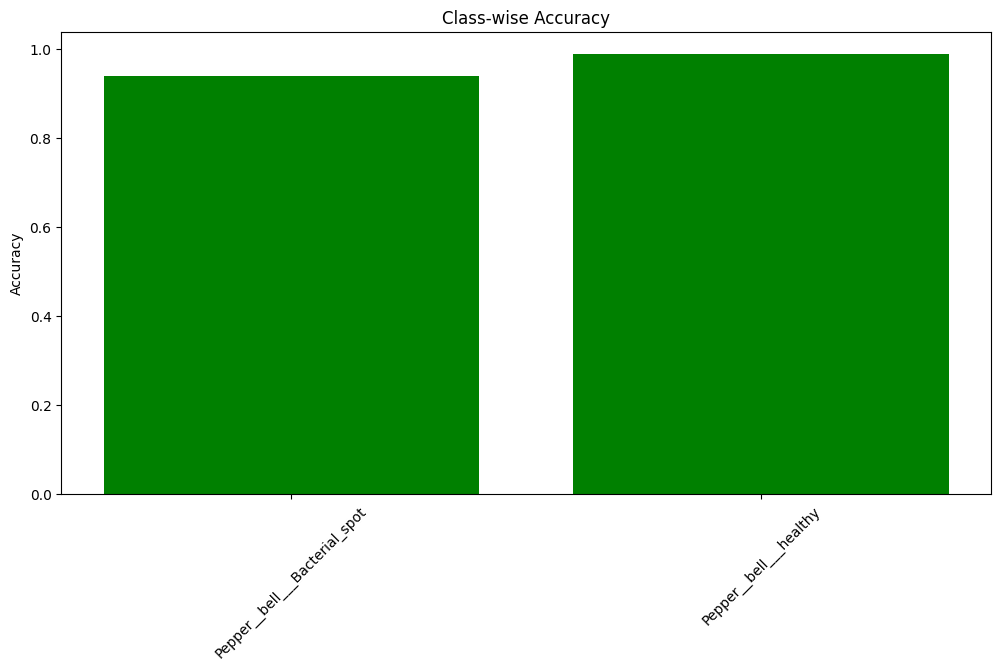

In [20]:
# Class-wise Accuracy Visualization
class_counts = dict.fromkeys(class_names, 0)
correct_counts = dict.fromkeys(class_names, 0)

for true, pred in zip(true_labels, pred_labels):
    class_counts[class_names[true]] += 1
    if true == pred:
        correct_counts[class_names[true]] += 1

classwise_acc = {cls: correct_counts[cls]/class_counts[cls] for cls in class_names}

plt.figure(figsize=(12, 6))
plt.bar(classwise_acc.keys(), classwise_acc.values(), color='green')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.show()


In [21]:
# Test with New Image

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)
    predictions = vit_model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(tf.nn.softmax(predictions))
    print(f"Predicted: {predicted_class} ({confidence:.2%})")


In [22]:
img_path = '/kaggle/input/working/test1.jpg'  # Use the actual path from the upload
predict_image(img_path)


1/1 [==============================] - 0s 38ms/step
Predicted: Pepper__bell___healthy (73.10%)


In [23]:
img_path = '/kaggle/input/working/test2.jpg'  # Use the actual path from the upload
predict_image(img_path)


1/1 [==============================] - 0s 35ms/step
Predicted: Pepper__bell___Bacterial_spot (65.80%)
